<a href="https://colab.research.google.com/github/YazanMaghary/Prediction-of-Product-Sales/blob/main/Prediction_of_Product_Sales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Prediction of Product Sales
- Author : Yazan Maghary

#### Project Overview:
1. ##### Load and inspect data
2. ##### Clean Data
3. ##### Exploratory Data Analysis
4. ##### Feature Inspection


### Load and inspect data

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
#calling the libraries and importing the data set
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
fname = "/content/drive/MyDrive/AXSOSACADEMY/01-Fundamentals/Project-1/sales_predictions_2023.csv"
df = pd.read_csv(fname)
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   object 
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


In [4]:
df.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


### Clean Data

In [5]:
#find duplicated and inspect them
df_duplicated = df.duplicated(keep=False)
df_duplicated.sum()
#for the firt impression , we can see that there are no duplicated rows in the data set , but we will deep dive to see if there and null values and check duplicated values again

np.int64(0)

There is no duplicated value in the data set

Checking null values

In [6]:
#check null values in the data set
null_values = df.isna().sum()
null_values

,0
Item_Identifier,0
Item_Weight,1463
Item_Fat_Content,0
Item_Visibility,0
Item_Type,0
Item_MRP,0
Outlet_Identifier,0
Outlet_Establishment_Year,0
Outlet_Size,2410
Outlet_Location_Type,0


In [7]:
df['Item_Weight'].isna().sum() # there is a 1463 null values need to be replaced with the mean value

np.int64(1463)

Assign -1 for every null value in item_wieght col

In [8]:
df['Item_Weight'] = df['Item_Weight'].fillna(-1)

In [9]:
#checking for null values in item_weight column after filling it
df['Item_Weight'].isna().sum()

np.int64(0)

In [10]:
df['Outlet_Size'].isna().sum() # there is a 2410 null values need to be replaced with the mode value

np.int64(2410)

Assign MISSING To every null value in Outlet_Size column

In [11]:
df['Outlet_Size'] = df['Outlet_Size'].fillna('MISSING')

In [12]:
#checking for null values in item_weight column after filling it
df['Outlet_Size'].isna().sum()

np.int64(0)

we find that there is a inconsistency in the data set as we have the same category with different names so we need to fix this

In [13]:
cat_cols = df.select_dtypes(include='object').columns
cat_cols

Index(['Item_Identifier', 'Item_Fat_Content', 'Item_Type', 'Outlet_Identifier',
       'Outlet_Size', 'Outlet_Location_Type', 'Outlet_Type'],
      dtype='object')

In [14]:

for col in cat_cols :
    print(f"{df[col].value_counts()}\n")

Item_Identifier
FDW13    10
FDG33    10
FDX31     9
FDT07     9
NCY18     9
         ..
FDO33     1
FDK57     1
FDT35     1
FDN52     1
FDE52     1
Name: count, Length: 1559, dtype: int64

Item_Fat_Content
Low Fat    5089
Regular    2889
LF          316
reg         117
low fat     112
Name: count, dtype: int64

Item_Type
Fruits and Vegetables    1232
Snack Foods              1200
Household                 910
Frozen Foods              856
Dairy                     682
Canned                    649
Baking Goods              648
Health and Hygiene        520
Soft Drinks               445
Meat                      425
Breads                    251
Hard Drinks               214
Others                    169
Starchy Foods             148
Breakfast                 110
Seafood                    64
Name: count, dtype: int64

Outlet_Identifier
OUT027    935
OUT013    932
OUT035    930
OUT049    930
OUT046    930
OUT045    929
OUT018    928
OUT017    926
OUT010    555
OUT019    528
Name: count,

Handling item fat content and combined the values that related to each other with one single value

In [15]:
df['Item_Fat_Content'] = df['Item_Fat_Content'].replace({"LF" : 'Low Fat' , "low fat" : "Low Fat" , "reg" : "Regular"})
df['Item_Fat_Content'].value_counts()

,count
Item_Fat_Content,
Low Fat,5517
Regular,3006


In [16]:
(df.nunique()  / len(df) )* 100

,0
Item_Identifier,18.291681
Item_Weight,4.880910
Item_Fat_Content,0.023466
Item_Visibility,92.455708
Item_Type,0.187727
Item_MRP,69.670304
Outlet_Identifier,0.117330
Outlet_Establishment_Year,0.105597
Outlet_Size,0.046932
Outlet_Location_Type,0.035199


The Summary of statistics for each numerical column

In [17]:
#show num col then obatain the agg methods for each num col
num_col = df.select_dtypes(include= 'number').columns
num_col

Index(['Item_Weight', 'Item_Visibility', 'Item_MRP',
       'Outlet_Establishment_Year', 'Item_Outlet_Sales'],
      dtype='object')

In [18]:
for col in num_col :
    print(f"{df[col].describe().round(2)}\n")


count    8523.00
mean       10.48
std         6.72
min        -1.00
25%         6.65
50%        11.00
75%        16.00
max        21.35
Name: Item_Weight, dtype: float64

count    8523.00
mean        0.07
std         0.05
min         0.00
25%         0.03
50%         0.05
75%         0.09
max         0.33
Name: Item_Visibility, dtype: float64

count    8523.00
mean      140.99
std        62.28
min        31.29
25%        93.83
50%       143.01
75%       185.64
max       266.89
Name: Item_MRP, dtype: float64

count    8523.00
mean     1997.83
std         8.37
min      1985.00
25%      1987.00
50%      1999.00
75%      2004.00
max      2009.00
Name: Outlet_Establishment_Year, dtype: float64

count     8523.00
mean      2181.29
std       1706.50
min         33.29
25%        834.25
50%       1794.33
75%       3101.30
max      13086.96
Name: Item_Outlet_Sales, dtype: float64



### Exploratory Data Analysis

In [19]:
df.head()


,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,MISSING,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [20]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                8523 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                8523 non-null   object 
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


['Solarize_Light2', '_classic_test_patch', '_mpl-gallery', '_mpl-gallery-nogrid', 'bmh', 'classic', 'dark_background', 'fast', 'fivethirtyeight', 'ggplot', 'grayscale', 'petroff10', 'seaborn-v0_8', 'seaborn-v0_8-bright', 'seaborn-v0_8-colorblind', 'seaborn-v0_8-dark', 'seaborn-v0_8-dark-palette', 'seaborn-v0_8-darkgrid', 'seaborn-v0_8-deep', 'seaborn-v0_8-muted', 'seaborn-v0_8-notebook', 'seaborn-v0_8-paper', 'seaborn-v0_8-pastel', 'seaborn-v0_8-poster', 'seaborn-v0_8-talk', 'seaborn-v0_8-ticks', 'seaborn-v0_8-white', 'seaborn-v0_8-whitegrid', 'tableau-colorblind10']


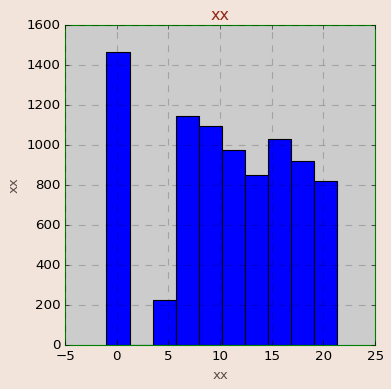

In [21]:
# for all graphs :
print(plt.style.available)
plt.style.use('classic')
plt.rcParams.update({'font.size': 12 , 'axes.facecolor' : (0.8, 0.8, 0.8) ,  'axes.edgecolor' : 'g' ,  'axes.labelcolor' : '5C4D4A' , 'axes.titlecolor' : '912716' ,'figure.facecolor' : 'F2E4DA' , 'figure.edgecolor' : 'w' ,  'grid.linestyle' : '--' ,  'grid.linewidth' : 1, 'grid.alpha' : 0.2 ,  'grid.color' : 'k'})

# test graph
fig ,ax = plt.subplots(figsize=(5,5))
ax.set_title("xx")
ax.set_xlabel("xx")
ax.set_ylabel("xx")
ax.grid()
ax.hist(df['Item_Weight'])
plt.show()


* Item Weight visualization using histogram graph

In [22]:
df['Item_Weight'].value_counts()

,count
Item_Weight,
-1.000,1463
12.150,86
17.600,82
13.650,77
11.800,76
...,...
5.210,2
9.420,1
7.685,1


In [23]:
df['Item_Weight'].describe()

,Item_Weight
count,8523.000000
mean,10.478936
std,6.720742
min,-1.000000
25%,6.650000
50%,11.000000
75%,16.000000
max,21.350000


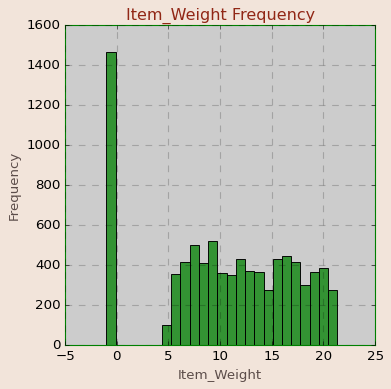

In [24]:
fig ,ax = plt.subplots(figsize=(5,5))
ax = sns.histplot(data=df , x='Item_Weight'  ,color='g')
ax.set_ylabel("Frequency")
ax.set_title("Item_Weight Frequency")
ax.grid()
plt.show()


* from rhe previous graph we can notice thats is a huge mount of missing data assigned to -1
* most of values are between 5 to 20 kg and there is a few values that are above 20 kg

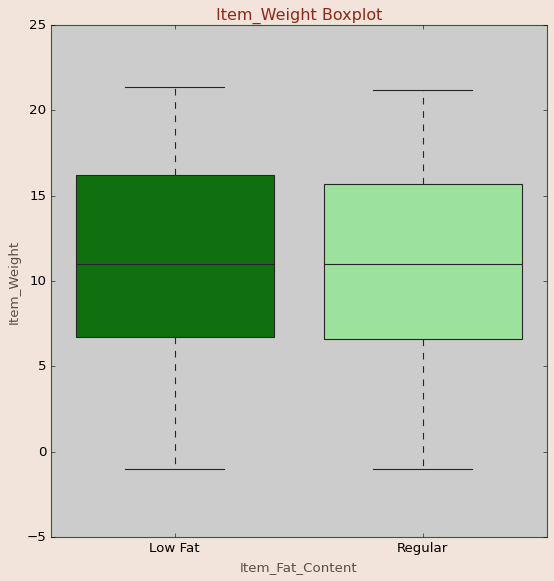

In [25]:
fig ,ax = plt.subplots(figsize=(8,8))
ax = sns.boxplot(data=df , y='Item_Weight',hue='Item_Fat_Content' ,palette=['g', 'lightgreen'] ,orient='v' , legend=False, x ='Item_Fat_Content' )
ax.set_title("Item_Weight Boxplot")
plt.show()


* there is no outliers depending on the boxplot graph
* interquartile range of low fat is bigger than regular fat content
* the missing value is affecting the data set

In [26]:
# for Item_Visibility
df['Item_Visibility'].value_counts()

,count
Item_Visibility,
0.000000,526
0.076975,3
0.061271,2
0.046825,2
0.112399,2
...,...
0.054142,1
0.018920,1
0.044974,1


In [27]:
df['Item_Visibility'].describe()

,Item_Visibility
count,8523.000000
mean,0.066132
std,0.051598
min,0.000000
25%,0.026989
50%,0.053931
75%,0.094585
max,0.328391


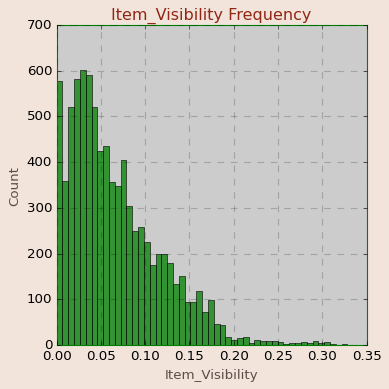

In [28]:
fig ,ax = plt.subplots(figsize=(5,5))
ax = sns.histplot(data=df , x='Item_Visibility' ,color='g')
ax.set_title("Item_Visibility Frequency")
ax.grid()
plt.show()

* its not a normal distribution and its sekwed to the left
* we can notice that most of values are between 0 to 0.25 and there is a few values that are above 0.25
* the most frequent value is 0 thats mean there is a huge mount of un visible items that have no spaces in the store in the data set
* most frequent values is between 0.01 to 0.05 that mean that the most of items are visible in the store with percent of availability between 1% to 5%
* thre is a few items that have a huge percent of availability that is above 0.25 to 0.35


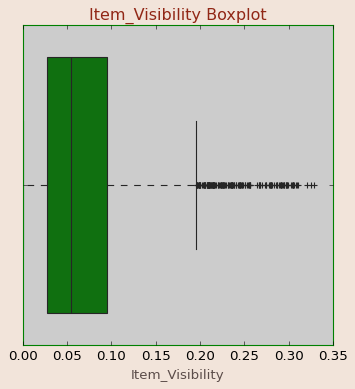

In [29]:
fig ,ax = plt.subplots(figsize=(5,5))
ax = sns.boxplot(data=df , x='Item_Visibility' ,color='g')
ax.set_title("Item_Visibility Boxplot")

plt.show()

* We can notice that item visiability had a lot of outliers and its skewed to the right

In [30]:
df['Item_MRP'].value_counts()

,count
Item_MRP,
172.0422,7
170.5422,6
142.0154,6
109.5228,6
188.1872,6
...,...
108.7912,1
157.5972,1
245.2118,1


In [31]:
df['Item_MRP'].describe()

,Item_MRP
count,8523.000000
mean,140.992782
std,62.275067
min,31.290000
25%,93.826500
50%,143.012800
75%,185.643700
max,266.888400


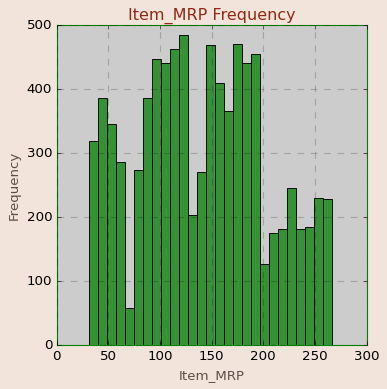

In [32]:
fig ,ax = plt.subplots(figsize=(5,5))
ax = sns.histplot(data=df , x='Item_MRP' ,color='g')
ax.set_ylabel("Frequency")
ax.set_title("Item_MRP Frequency")
ax.grid()
plt.show()

Text(0.5, 1.0, 'Item_MRP Boxplot')

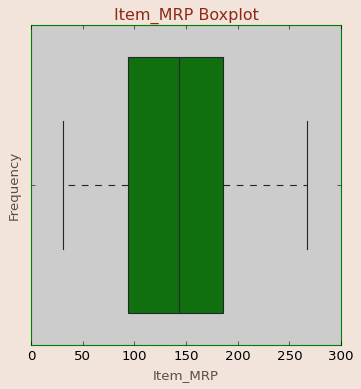

In [33]:
fig ,ax = plt.subplots(figsize=(5,5))
ax = sns.boxplot(data=df , x='Item_MRP' ,color='g')
ax.set_ylabel("Frequency")
ax.set_title("Item_MRP Boxplot")

* its skewed to the right
* its seem that is no missing or outlier values in the data set
* all the values are between 30 to 270 that mean that the most of items have a price between 0 to 300
* about 25% of your MRP are below 100
* about 50% of your MRP are below 150
* about 75% of your MRP are below 190

In [34]:
df['Outlet_Establishment_Year'].value_counts()

,count
Outlet_Establishment_Year,
1985,1463
1987,932
1999,930
1997,930
2004,930
2002,929
2009,928
2007,926
1998,555


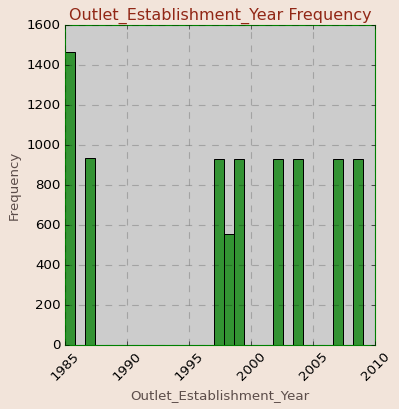

In [35]:
fig ,ax = plt.subplots(figsize=(5,5))
ax = sns.histplot(data=df , x='Outlet_Establishment_Year' ,color='g' ,bins=30)
ax.set_ylabel("Frequency")
ax.set_title("Outlet_Establishment_Year Frequency")
ax.ticklabel_format(style='plain', axis='x',useOffset=False )
ax.tick_params(axis='x', rotation=45)
ax.grid()
plt.show()

* we can notice that most stores are established in 1985
* all stores are established between 1985 to 2009
* the time between 1990 to 1995 have no store established

In [36]:
df['Item_Outlet_Sales'].describe()


,Item_Outlet_Sales
count,8523.000000
mean,2181.288914
std,1706.499616
min,33.290000
25%,834.247400
50%,1794.331000
75%,3101.296400
max,13086.964800


In [37]:
df['Item_Outlet_Sales'].value_counts()

,count
Item_Outlet_Sales,
958.7520,17
1342.2528,16
703.0848,15
1845.5976,15
1278.3360,14
...,...
2224.4378,1
2419.5172,1
4111.3150,1


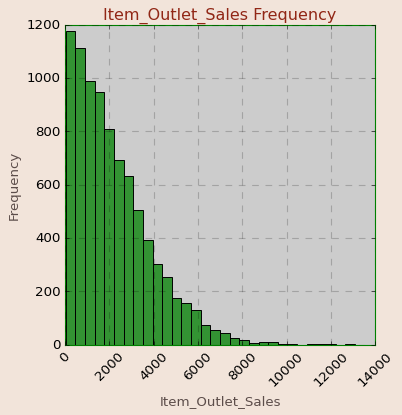

In [38]:

fig ,ax = plt.subplots(figsize=(5,5))
ax = sns.histplot(data=df , x='Item_Outlet_Sales' ,color='g' ,bins=30)
ax.set_ylabel("Frequency")
ax.set_title("Item_Outlet_Sales Frequency")
ax.ticklabel_format(style='plain', axis='x',useOffset=False )
ax.tick_params(axis='x', rotation=45)
ax.grid()
plt.show()

* most frequent items is between 0 to 2000 that mean that the most of sales are between 0 to 2000
* this Right-Skewed Distribution
* when the item rise we notice that the number of sales decrease

Text(0.5, 1.0, 'Item_MRP Boxplot')

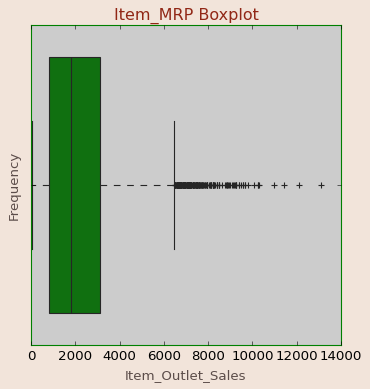

In [39]:
fig ,ax = plt.subplots(figsize=(5,5))
ax = sns.boxplot(data=df , x='Item_Outlet_Sales' ,color='g')
ax.set_ylabel("Frequency")
ax.set_title("Item_MRP Boxplot")


* the sales is frequent betwwen 0 to 6000 that mean that the most of sales are between 0 to 6000
* mean is almots 2000
* there is a lot of outliers begining from 6000
* the graph skewed to the right
* about 25% of your sales are below 800
* about 50% of your sales are below 2000
* about 75% of your sales are below 3500

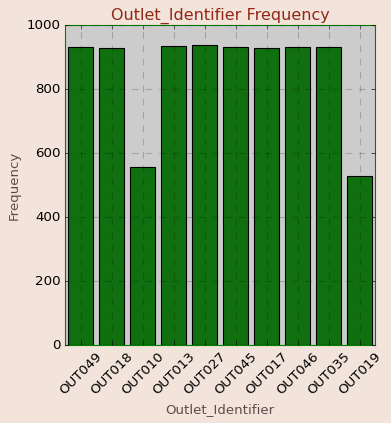

,count
Outlet_Identifier,
OUT027,935
OUT013,932
OUT035,930
OUT049,930
OUT046,930
OUT045,929
OUT018,928
OUT017,926
OUT010,555


In [40]:
# count plot for categorical features
fig ,ax = plt.subplots(figsize=(5,5))
ax = sns.countplot(data=df , x='Outlet_Identifier' ,color='g')
ax.set_ylabel("Frequency")
ax.set_title("Outlet_Identifier Frequency")
# ax.ticklabel_format(style='plain', axis='x',useOffset=False )
ax.tick_params(axis='x', rotation=45)
ax.grid()
plt.show()
df['Outlet_Identifier'].value_counts()

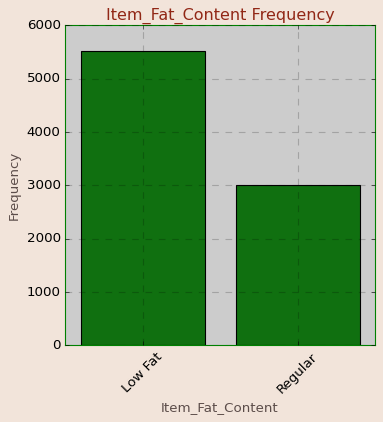

,count
Item_Fat_Content,
Low Fat,5517
Regular,3006


In [41]:
# count plot for categorical features
fig ,ax = plt.subplots(figsize=(5,5))
ax = sns.countplot(data=df , x='Item_Fat_Content' ,color='g')
ax.set_ylabel("Frequency")
ax.set_title("Item_Fat_Content Frequency")
# ax.ticklabel_format(style='plain', axis='x',useOffset=False )
ax.tick_params(axis='x', rotation=45)
ax.grid()
plt.show()
df['Item_Fat_Content'].value_counts()

* we can notice that low fat items are more than regular fat items with huge diffrent of frquency that mean that low fat items are more popular than regular fat items

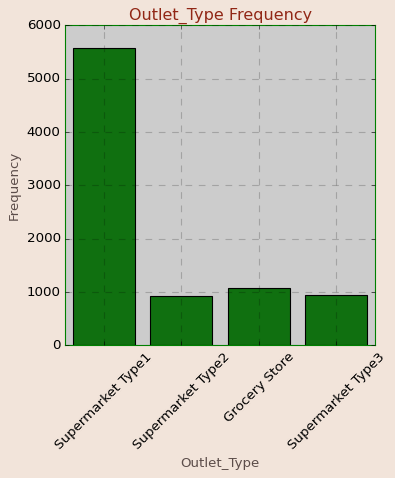

,count
Outlet_Type,
Supermarket Type1,5577
Grocery Store,1083
Supermarket Type3,935
Supermarket Type2,928


In [42]:
# count plot for categorical features
fig ,ax = plt.subplots(figsize=(5,5))
ax = sns.countplot(data=df , x='Outlet_Type' ,color='g')
ax.set_ylabel("Frequency")
ax.set_title("Outlet_Type Frequency")
# ax.ticklabel_format(style='plain', axis='x',useOffset=False )
ax.tick_params(axis='x', rotation=45)
ax.grid()
plt.show()

df['Outlet_Type'].value_counts()

* we notice that the most popular market types is Supermarket Type1 store with huge diffrent of frquency that mean that Supermarket Type1  is more popular than other market types

In [43]:
#Heat Map
corr = df.corr(numeric_only=True)
corr

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales
Item_Weight,1.000000,-0.079371,0.022367,0.537341,-0.055461
Item_Visibility,-0.079371,1.000000,-0.001315,-0.074834,-0.128625
Item_MRP,0.022367,-0.001315,1.000000,0.005020,0.567574
Outlet_Establishment_Year,0.537341,-0.074834,0.005020,1.000000,-0.049135
Item_Outlet_Sales,-0.055461,-0.128625,0.567574,-0.049135,1.000000


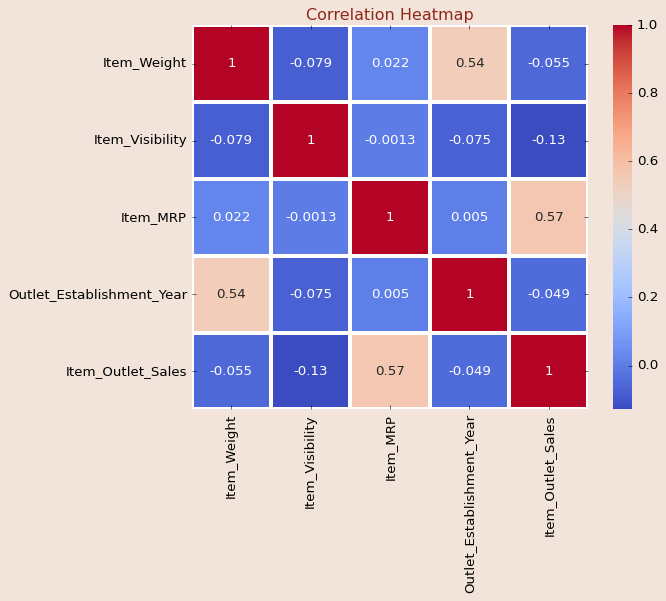

In [44]:
fig ,ax = plt.subplots()
sns.heatmap(data=corr ,annot=True, cmap='coolwarm', linewidths=2 )
ax.set_title("Correlation Heatmap")
plt.show()


* There is no strong correlation between the features that we have in the data set

### Feature Inspection